In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# Run 15: full (ranked + aggregated) feature set. BEST_NUM_FEATS comes from the FULL run's
# get_best_num_features(.005) in rfe.ipynb (=31, NOT the rank-only 17); source CSV is the _full trace.
BEST_NUM_FEATS = 31
SELECTED_RFE_CSV = 'rfe_features_kfolds_full.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63527	validation_1-auc:0.62926
[1]	validation_0-auc:0.66248	validation_1-auc:0.62650
[2]	validation_0-auc:0.67074	validation_1-auc:0.62631
[3]	validation_0-auc:0.68107	validation_1-auc:0.63028
[0]	validation_0-auc:0.63232	validation_1-auc:0.60821
[4]	validation_0-auc:0.68755	validation_1-auc:0.63929
[1]	validation_0-auc:0.65657	validation_1-auc:0.62911
[5]	validation_0-auc:0.68942	validation_1-auc:0.63781
[2]	validation_0-auc:0.67159	validation_1-auc:0.64031
[6]	validation_0-auc:0.69245	validation_1-auc:0.63903
[3]	validation_0-auc:0.67798	validation_1-auc:0.64626
[7]	validation_0-auc:0.69373	validation_1-auc:0.63892
[4]	validation_0-auc:0.68469	validation_1-auc:0.65272
[8]	validation_0-auc:0.69411	validation_1-auc:0.64304
[9]	validation_0-auc:0.69762	validation_1-auc:0.64629
[5]	validation_0-auc:0.69175	validation_1-auc:0.65677
[10]	validation_0-auc:0.70156	validation_1-auc:0.64691
[6]	validation_0-auc:0.69622	validation_1-auc:0.66039
[11]	validation_0-auc:0.703

[8]	validation_0-auc:0.70358	validation_1-auc:0.65275
[24]	validation_0-auc:0.72816	validation_1-auc:0.65229
[1]	validation_0-auc:0.64957	validation_1-auc:0.63194
[35]	validation_0-auc:0.69215	validation_1-auc:0.65820
[38]	validation_0-auc:0.71923	validation_1-auc:0.65639
[24]	validation_0-auc:0.69145	validation_1-auc:0.63989
[38]	validation_0-auc:0.73495	validation_1-auc:0.65623
[6]	validation_0-auc:0.69858	validation_1-auc:0.65632
[22]	validation_0-auc:0.68147	validation_1-auc:0.65431
[41]	validation_0-auc:0.69597	validation_1-auc:0.65586
[9]	validation_0-auc:0.70550	validation_1-auc:0.65158
[43]	validation_0-auc:0.69765	validation_1-auc:0.65626
[39]	validation_0-auc:0.71944	validation_1-auc:0.65615
[36]	validation_0-auc:0.69225	validation_1-auc:0.65890
[25]	validation_0-auc:0.72836	validation_1-auc:0.65438
[25]	validation_0-auc:0.69277	validation_1-auc:0.64019
[27]	validation_0-auc:0.72755	validation_1-auc:0.64463
[2]	validation_0-auc:0.66253	validation_1-auc:0.63508
[7]	validation_

[3]	validation_0-auc:0.66963	validation_1-auc:0.63949
[26]	validation_0-auc:0.70036	validation_1-auc:0.64418
[35]	validation_0-auc:0.70240	validation_1-auc:0.66141
[21]	validation_0-auc:0.69314	validation_1-auc:0.66509
[4]	validation_0-auc:0.67382	validation_1-auc:0.63588
[32]	validation_0-auc:0.70067	validation_1-auc:0.65487
[34]	validation_0-auc:0.71850	validation_1-auc:0.65819
[33]	validation_0-auc:0.71884	validation_1-auc:0.66274
[27]	validation_0-auc:0.70094	validation_1-auc:0.64393
[36]	validation_0-auc:0.70265	validation_1-auc:0.66120
[6]	validation_0-auc:0.68300	validation_1-auc:0.64837
[4]	validation_0-auc:0.67601	validation_1-auc:0.64136
[22]	validation_0-auc:0.69392	validation_1-auc:0.66560
[5]	validation_0-auc:0.67634	validation_1-auc:0.63369
[33]	validation_0-auc:0.70136	validation_1-auc:0.65460
[34]	validation_0-auc:0.71948	validation_1-auc:0.66265
[28]	validation_0-auc:0.70130	validation_1-auc:0.64385
[37]	validation_0-auc:0.70205	validation_1-auc:0.65606
[37]	validation

[24]	validation_0-auc:0.63467	validation_1-auc:0.61830
[15]	validation_0-auc:0.68911	validation_1-auc:0.66193
[23]	validation_0-auc:0.69823	validation_1-auc:0.65660
[11]	validation_0-auc:0.68976	validation_1-auc:0.64099
[28]	validation_0-auc:0.64447	validation_1-auc:0.61919
[33]	validation_0-auc:0.63520	validation_1-auc:0.61275
[8]	validation_0-auc:0.64638	validation_1-auc:0.62032
[17]	validation_0-auc:0.68988	validation_1-auc:0.65631
[25]	validation_0-auc:0.63467	validation_1-auc:0.61830
[7]	validation_0-auc:0.64508	validation_1-auc:0.60533
[16]	validation_0-auc:0.69110	validation_1-auc:0.66260
[24]	validation_0-auc:0.69911	validation_1-auc:0.65547
[29]	validation_0-auc:0.64883	validation_1-auc:0.62698
[12]	validation_0-auc:0.69043	validation_1-auc:0.64165
[34]	validation_0-auc:0.63520	validation_1-auc:0.61275
[9]	validation_0-auc:0.64638	validation_1-auc:0.62032
[18]	validation_0-auc:0.69440	validation_1-auc:0.65210
[18]	validation_0-auc:0.69167	validation_1-auc:0.65635
[26]	validati

[15]	validation_0-auc:0.67411	validation_1-auc:0.64312
[39]	validation_0-auc:0.65476	validation_1-auc:0.64149
[24]	validation_0-auc:0.70146	validation_1-auc:0.66144
[22]	validation_0-auc:0.69904	validation_1-auc:0.66114
[19]	validation_0-auc:0.67368	validation_1-auc:0.64108
[37]	validation_0-auc:0.64877	validation_1-auc:0.63412
[27]	validation_0-auc:0.68192	validation_1-auc:0.63602
[28]	validation_0-auc:0.70272	validation_1-auc:0.65877
[16]	validation_0-auc:0.67541	validation_1-auc:0.64343
[25]	validation_0-auc:0.67645	validation_1-auc:0.65156
[38]	validation_0-auc:0.64877	validation_1-auc:0.63412
[20]	validation_0-auc:0.67437	validation_1-auc:0.64040
[25]	validation_0-auc:0.70189	validation_1-auc:0.66123
[23]	validation_0-auc:0.69996	validation_1-auc:0.66248
[16]	validation_0-auc:0.69460	validation_1-auc:0.64871
[17]	validation_0-auc:0.67585	validation_1-auc:0.64328
[26]	validation_0-auc:0.67862	validation_1-auc:0.65243
[29]	validation_0-auc:0.70262	validation_1-auc:0.65821
[39]	valid

...

[46]	validation_0-auc:0.72572	validation_1-auc:0.65727


[47]	validation_0-auc:0.72633	validation_1-auc:0.65791


[48]	validation_0-auc:0.72652	validation_1-auc:0.65815


[49]	validation_0-auc:0.72684	validation_1-auc:0.65846




Best parameters found:  {'subsample': 0.5, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.1, 'importance_type': 'total_gain', 'gamma': 1, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.6859596876247341


Best Selected Features:  ['off_target_seconds_per_play_garbage_leading_cumulative_average', 'off_target_epa_per_play_competitive_cumulative_average', 'off_target_rush_epa_per_carry_garbage_leading_cumulative_average', 'is_home_target', 'opp_def_cumulative_avg_points_allowed', 'off_opp_early_down_success_rate_competitive_cumulative_average', 'def_opp_run_middle_explosive_rate_competitive_cumulative_average', 'def_target_rushing_yards_cumulative_average', 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average', 'off_target_run_middle_yards_per_attempt_competitive_cumulative_average', 'off_target_success_rate_competitive_cumulative_average', 'def_opp_seconds_per_play_garbage_leading_cumulative_average', 'of

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.17162886, 0.20097928, 0.16972604, 0.17736573, 0.19058805,
        0.07664723, 0.09858265, 0.0927125 , 0.14589567, 0.14442687,
        0.07547698, 0.06537223, 0.15003653, 0.14175119, 0.19810944,
        0.10698814, 0.09625463, 0.10136013, 0.0985394 , 0.06519718,
        0.06551914, 0.09349475, 0.14526629, 0.14207678, 0.15172901,
        0.22428665, 0.09663019, 0.08859339, 0.14753056, 0.14754443,
        0.12852554, 0.21533446, 0.09583802, 0.18633142, 0.06903729,
        0.06715617, 0.10889649, 0.13810053, 0.07903328, 0.09986739,
        0.17947664, 0.19487696, 0.07705069, 0.10151076, 0.13433232,
        0.07212105, 0.06180682, 0.09645729, 0.12371559, 0.18646603,
        0.13527508, 0.06977315, 0.1934423 , 0.06137295, 0.16708899,
        0.10289049, 0.21378703, 0.06740522, 0.16889648, 0.07663736,
        0.1377718 , 0.1333271 , 0.07045784, 0.06740346, 0.10732312,
        0.1260273 , 0.10205359, 0.10136719, 0.12808061, 0.18725195,
        0.1122364 , 0.09586143,

<Axes: >

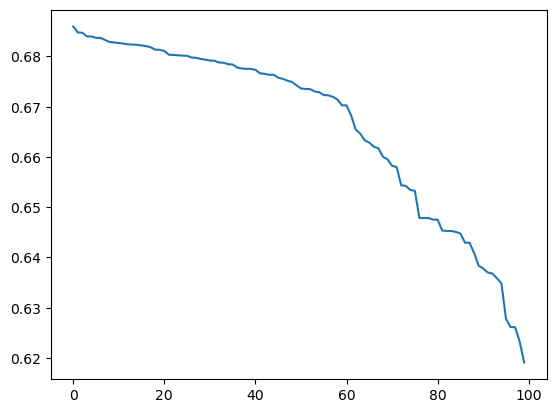

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.213787,0.008538,0.002556,0.000112,0.5,50,50,3,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.674527,0.686339,0.678231,0.682932,0.707769,0.685960,0.011622,1
1,0.171459,0.020049,0.002884,0.001377,0.5,50,10,2,0.2,total_gain,...,20,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.682338,0.676995,0.666693,0.687524,0.710333,0.684776,0.014520,2
2,0.159599,0.017862,0.002772,0.000802,0.7,40,100,3,0.2,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.685335,0.675176,0.670305,0.687003,0.705705,0.684705,0.012205,3
3,0.177366,0.014134,0.003143,0.001297,0.7,40,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.683502,0.675590,0.668560,0.688239,0.704043,0.683987,0.012075,4
4,0.215334,0.012683,0.004078,0.002113,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.682900,0.675590,0.668560,0.688777,0.704043,0.683974,0.012123,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6387867647058824

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Run 15: single overall hold-out AUROC, computed exactly like bart.ipynb, for a clean
# apples-to-apples comparison against the 0.705 champion.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, full set]')

2024+2025 hold-out ROC-AUC (overall): 0.6981  [31 features, full set]


In [13]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.225654
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.793415
2,2024_01_BAL_KC,1,KC,BAL,1,0.404814
3,2024_01_BAL_KC,1,BAL,KC,0,0.455593
4,2024_01_CAR_NO,1,CAR,NO,0,0.237785
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.523044
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.765333
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.229130
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.713160


week
1     0.839844
2     0.651367
3     0.539062
4     0.636719
5     0.480867
6     0.763377
7     0.812222
8     0.728894
9     0.769322
10    0.640306
11    0.721760
12    0.766804
13    0.722656
14    0.769547
15    0.813477
16    0.673828
17    0.665039
18    0.604492
dtype: float64

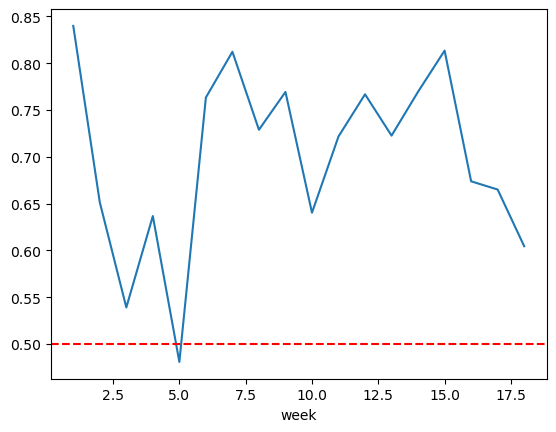

In [14]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [15]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.838542
2     0.591093
3     0.666667
4     0.646825
5     0.583333
6     0.535714
7     0.850000
8     0.594444
9     0.627778
10    0.661458
11    0.691919
12    0.657895
13    0.733333
14    0.684211
15    0.705314
16    0.603239
17    0.562771
18    0.635294
dtype: float64

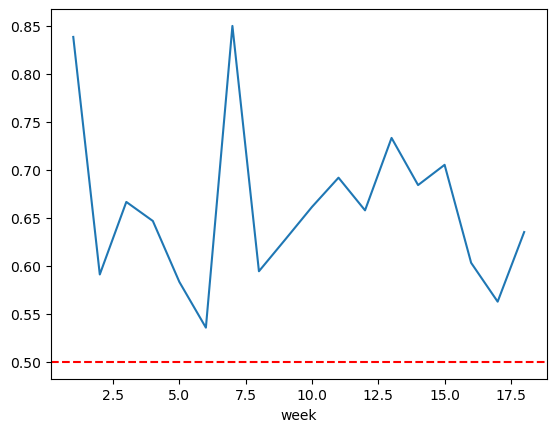

In [16]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [17]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2204  (lower is better; 0.25 = coin flip)
Log loss:    0.6309  (lower is better; punishes confident-and-wrong hardest)


In [18]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",219,0.561644,0.554235,-0.007409
"(0.6, 0.7]",183,0.672131,0.647361,-0.024770
"(0.7, 0.8]",97,0.742268,0.742650,0.000382
"(0.8, 0.9]",14,0.928571,0.817638,-0.110934


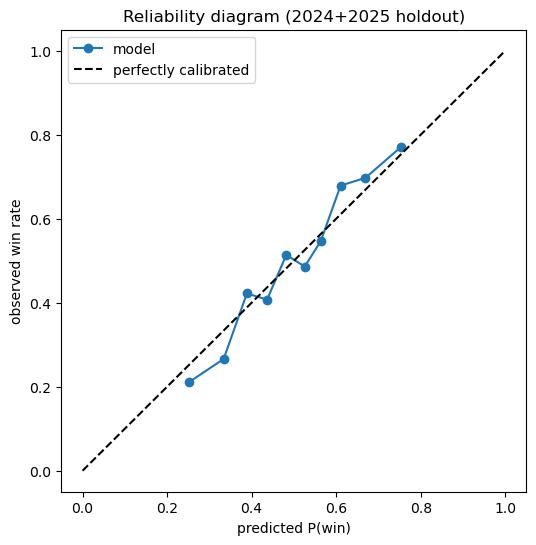

In [19]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [20]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.264


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(0.0014399999999999999, 0.08]",109,0.041714,0.440367
"(0.08, 0.17]",109,0.121713,0.513761
"(0.17, 0.264]",108,0.214716,0.685185
"(0.264, 0.405]",109,0.333354,0.706422
"(0.405, 0.703]",109,0.493261,0.788991


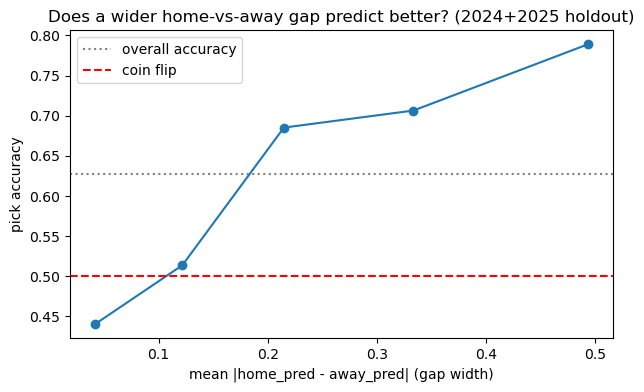

In [21]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()